In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

### Calcolo integrale con importance sampling

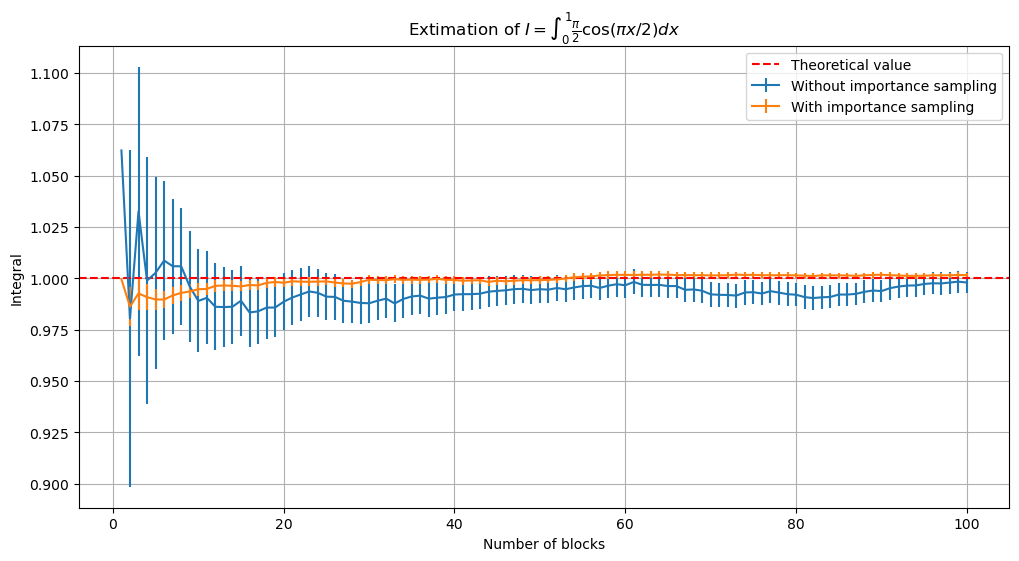

In [2]:
plt.figure(figsize=(12,6))
x, f1, error1 = np.loadtxt("Punto1.txt", usecols=(0,1,2), delimiter=' ', unpack=True)
f2, error2 = np.loadtxt("Punto2.txt", usecols=(1,2), delimiter=' ', unpack=True)
plt.errorbar(x,f1,yerr=error1, label="Without importance sampling")
plt.errorbar(x,f2,yerr=error2, label="With importance sampling")
plt.axhline(y=1, color="r", linestyle="--", label="Theoretical value")
plt.title(r"Extimation of $I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx$")
plt.xlabel('Number of blocks')
plt.ylabel('Integral')
plt.grid(True)
plt.legend()

plt.show()

### Commenti
Per fare Importance Sampling, è stato preso lo sviluppo al primo ordine di $\cos(\frac{\pi}{2}x)$ attorno ad 1, cioè:
$$\cos\left(\frac{\pi}{2}x\right) = 0 - \frac{\pi}{2}(x-1) + \dots = \frac{\pi}{2}(1-x) + \dots$$
Procediamo poi a normalizzare la funzione in modo da poterla prendere come distribuzione di probabilità $p(x)$:
$$\int_0^1\frac{\pi}{2} (1-x) dx = \frac{\pi}{4}$$
$$p(x) = \frac{\pi}{2} (1-x) \cdot \frac{1}{\frac{\pi}{4}} = 2(1-x)$$
Per poter estrarre uniformemente tra $[0,1]$ dobbiamo calcolare la cumulativa $y$ di $p(x)$ ed invertirla:
$$y = \int_0^x p(x)dx = \int_0^x 2(1-x)dx = 2x-x^2$$
ed invertendo:
$$x = 1 \pm\sqrt{1-y}$$
Scegliamo la radice con il $-$ in quanto ha il minimo uguale a 0 e il massimo uguale a 1.\
Otteniamo quindi:
$$\int_0^1 \frac{\pi}{2}\cos\left(\frac{\pi}{2}x\right) \, dx = \int_0^1 \frac{\pi \cos\left(\frac{\pi}{2} x'\right)}{4(1-x')} \, dx'$$
con $x'=1-\sqrt{1-y}$ e $y\in[0,1)$ uniformemente.\
Come si può notare dal grafico sopra riportato, l'utilizzo dell'Importance Sampling fa diminuire drasticamente l'errore (circa 4 volte).
